In [152]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
foods = pd.read_csv('../data/processed/foods_cleaned.csv')

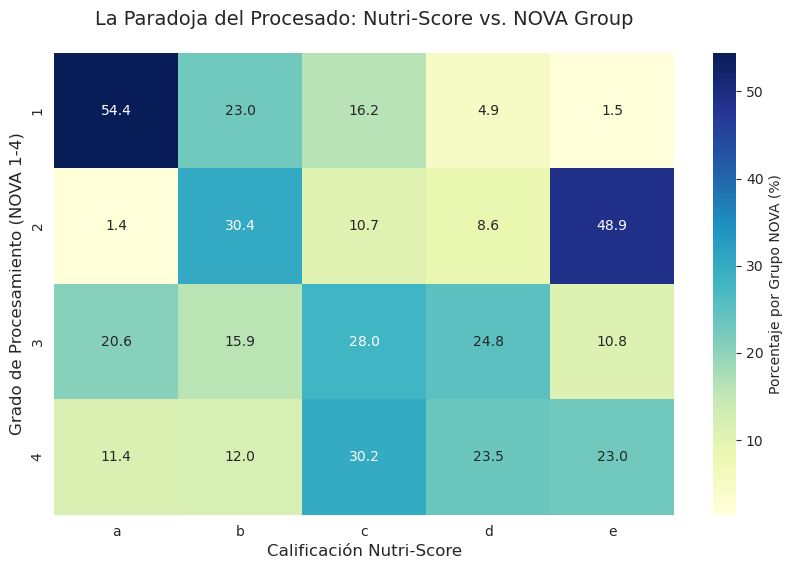

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos un DataFrame temporal filtrando el "ruido"
# Excluimos 'not-applicable', 'unknown' y el grupo 0 de NOVA
df_paradox = foods[
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])) & 
    (foods['nova_group'] > 0)
].copy()

# 2. Generamos la tabla cruzada con porcentajes por fila (frecuencia relativa)
cross_tab = pd.crosstab(
    df_paradox['nova_group'], 
    df_paradox['nutriscore_grade'], 
    normalize='index'
) * 100

# 3. Reordenamos las columnas para asegurar la jerarquía A -> E
cross_tab = cross_tab.reindex(columns=['a', 'b', 'c', 'd', 'e'])

# 4. Configuración y visualización del Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    cross_tab, 
    annot=True, 
    cmap="YlGnBu", 
    fmt=".1f", 
    cbar_kws={'label': 'Porcentaje por Grupo NOVA (%)'}
)

plt.title("La Paradoja del Procesado: Nutri-Score vs. NOVA Group", fontsize=14, pad=20)
plt.ylabel("Grado de Procesamiento (NOVA 1-4)", fontsize=12)
plt.xlabel("Calificación Nutri-Score", fontsize=12)

plt.show()

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definimos los nutrientes que penalizan (negativos) y favorecen (positivos)
nutrientes_clave = ['energy-kcal_100g', 'sugars_100g', 'saturated-fat_100g', 'salt_100g', 'fiber_100g', 'proteins_100g']

# Creamos un dataset numérico para la correlación
# Convertimos las letras a números para poder correlacionar: a=5, b=4, c=3, d=2, e=1
df_corr = foods[foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])].copy()
df_corr['nutri_numeric'] = df_corr['nutriscore_grade'].map({'a':5, 'b':4, 'c':3, 'd':2, 'e':1})

# Elegimos una categoría para el test (ejemplo: snacks_sweets)
cat_test = 'snacks_sweets'
data_cat = df_corr[df_corr['category_unified'] == cat_test]

# Calculamos la correlación
correlaciones = data_cat[nutrientes_clave + ['nutri_numeric']].corr()['nutri_numeric'].sort_values()

print(f"Análisis para {cat_test}:")
print(correlaciones)

Análisis para snacks_sweets:
sugars_100g          -0.643572
energy-kcal_100g     -0.559269
saturated-fat_100g   -0.498605
salt_100g            -0.057755
fiber_100g            0.147192
proteins_100g         0.148988
nutri_numeric         1.000000
Name: nutri_numeric, dtype: float64


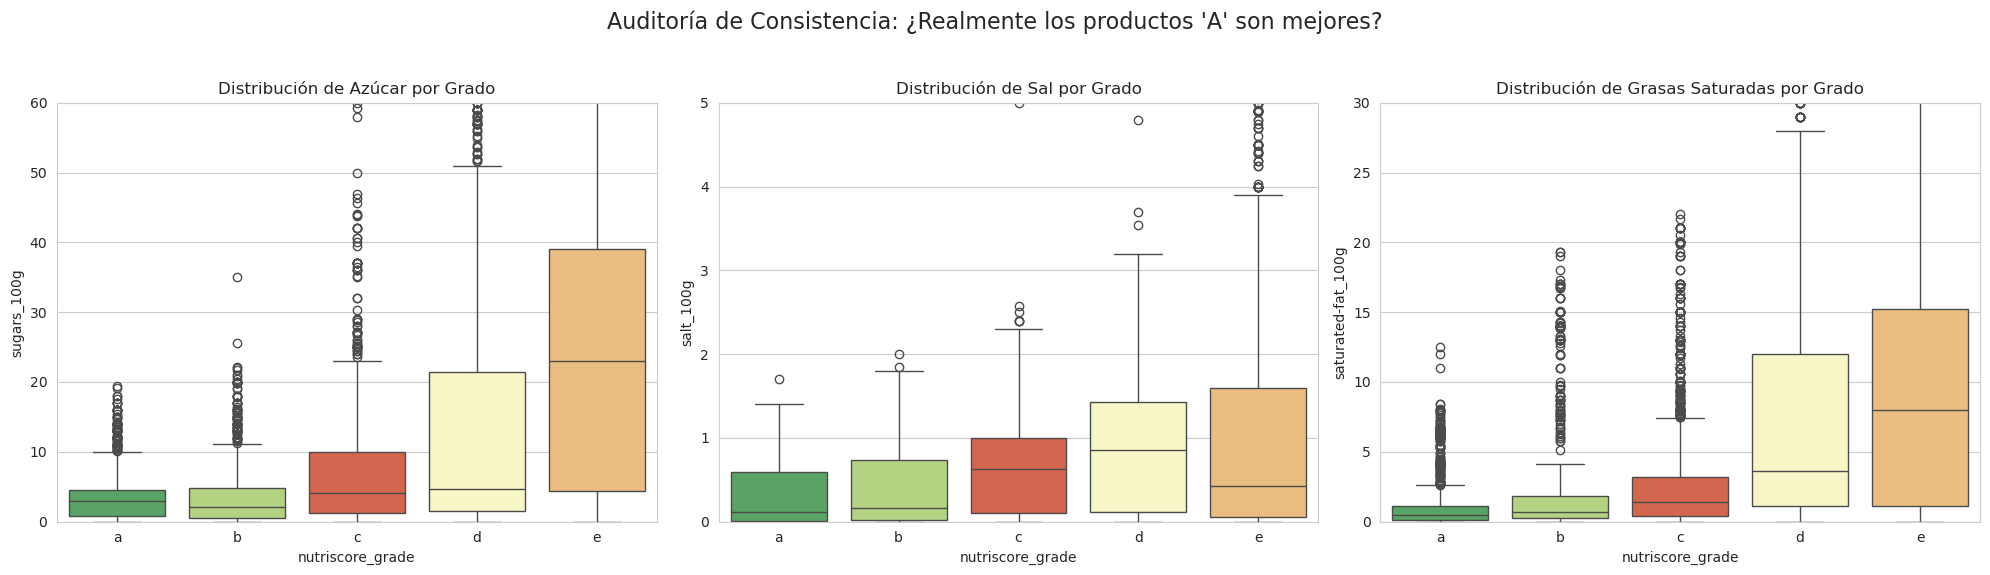

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtramos solo los productos con nota válida
df_veracidad = foods[foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])].copy()

# 2. Configuramos el lienzo
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
order = ['a', 'b', 'c', 'd', 'e']
palette = "RdYlGn_r"

# Gráfico 1: Azúcares
# Añadimos hue='nutriscore_grade' y legend=False para cumplir con la nueva API
sns.boxplot(ax=axes[0], x='nutriscore_grade', y='sugars_100g', data=df_veracidad, 
            order=order, palette=palette, hue='nutriscore_grade', legend=False)
axes[0].set_title('Distribución de Azúcar por Grado')
axes[0].set_ylim(0, 60)

# Gráfico 2: Sal
sns.boxplot(ax=axes[1], x='nutriscore_grade', y='salt_100g', data=df_veracidad, 
            order=order, palette=palette, hue='nutriscore_grade', legend=False)
axes[1].set_title('Distribución de Sal por Grado')
axes[1].set_ylim(0, 5)

# Gráfico 3: Grasas Saturadas
sns.boxplot(ax=axes[2], x='nutriscore_grade', y='saturated-fat_100g', data=df_veracidad, 
            order=order, palette=palette, hue='nutriscore_grade', legend=False)
axes[2].set_title('Distribución de Grasas Saturadas por Grado')
axes[2].set_ylim(0, 30)

plt.suptitle("Auditoría de Consistencia: ¿Realmente los productos 'A' son mejores?", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

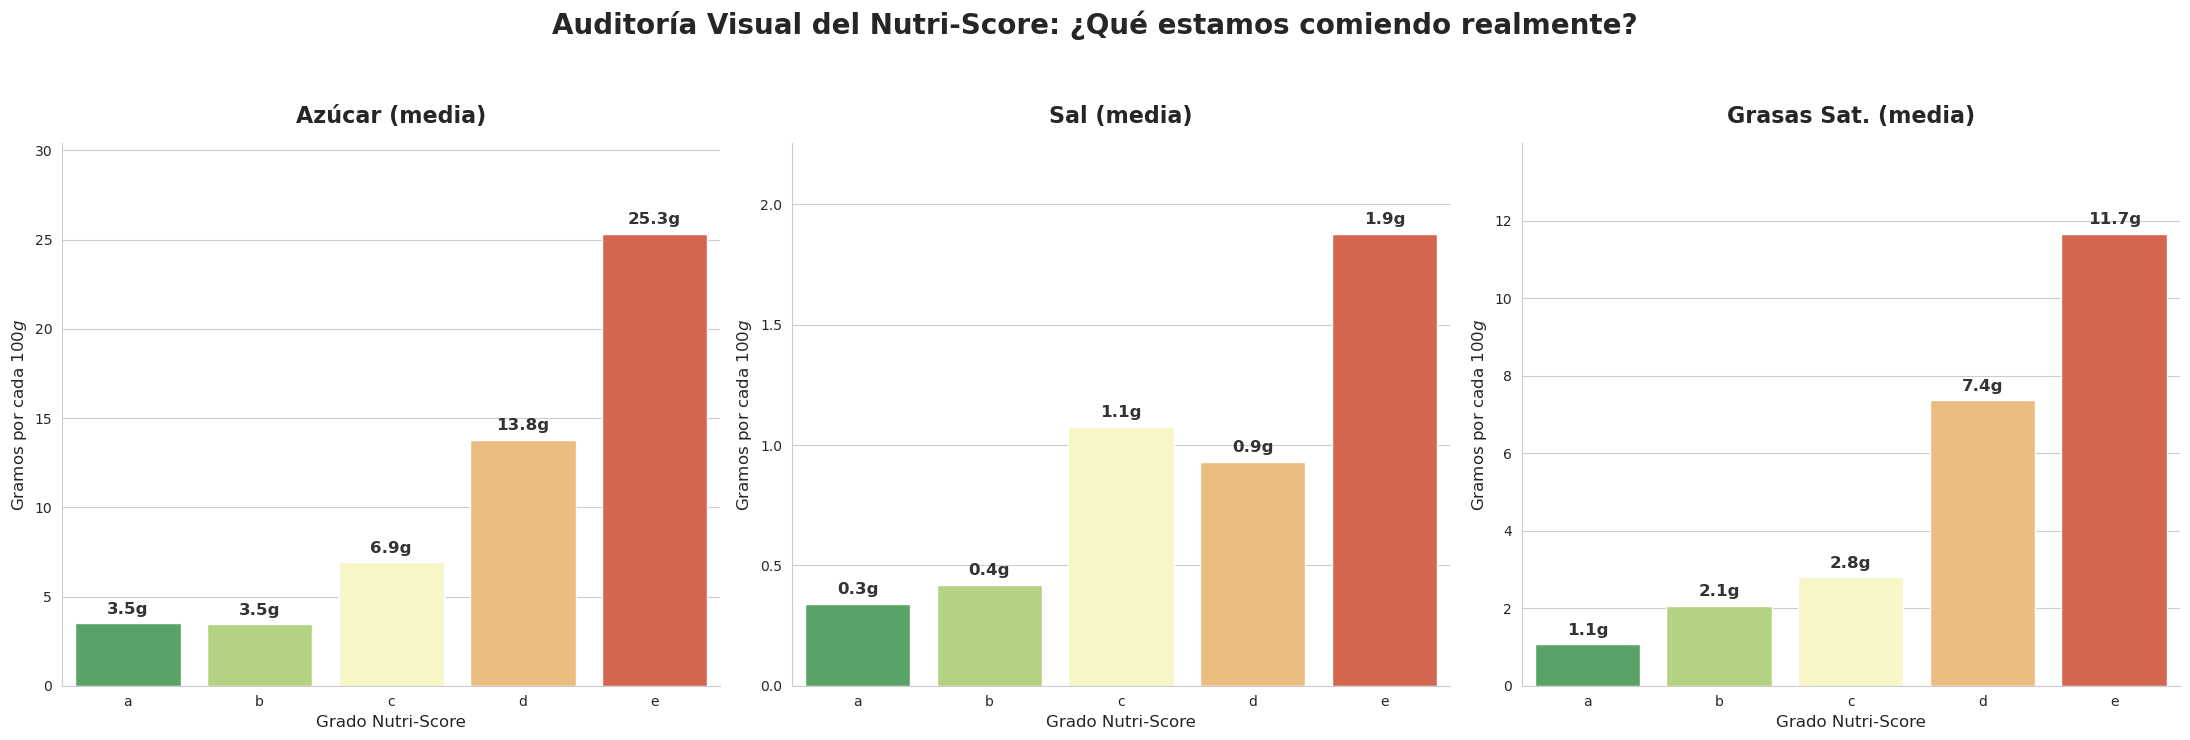

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparación de datos: calculamos las medias por grado
df_veracidad = foods[foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])].copy()
nutrientes = ['sugars_100g', 'salt_100g', 'saturated-fat_100g']
titulos = ['Azúcar (media)', 'Sal (media)', 'Grasas Sat. (media)']
unidades = ['g', 'g', 'g']

medias = df_veracidad.groupby('nutriscore_grade')[nutrientes].mean().reset_index()

# 2. Configuración estética
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
palette = "RdYlGn_r"
order = ['a', 'b', 'c', 'd', 'e']

# 3. Generación de los 3 subplots
for i, nutriente in enumerate(nutrientes):
    ax = sns.barplot(
        ax=axes[i], 
        x='nutriscore_grade', 
        y=nutriente, 
        data=medias, 
        order=order, 
        palette=palette, 
        hue='nutriscore_grade', 
        legend=False
    )
    
    # Añadimos etiquetas de valor sobre cada barra
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}{unidades[i]}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points', 
                    fontsize=12, fontweight='bold', color='#333333')

    # Personalización de cada gráfico
    ax.set_title(titulos[i], fontsize=16, pad=15, fontweight='bold')
    ax.set_ylabel(f"Gramos por cada 100$g$", fontsize=12)
    ax.set_xlabel("Grado Nutri-Score", fontsize=12)
    ax.set_ylim(0, medias[nutriente].max() * 1.2) # Espacio para la etiqueta
    sns.despine(ax=ax)

plt.suptitle("Auditoría Visual del Nutri-Score: ¿Qué estamos comiendo realmente?", fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

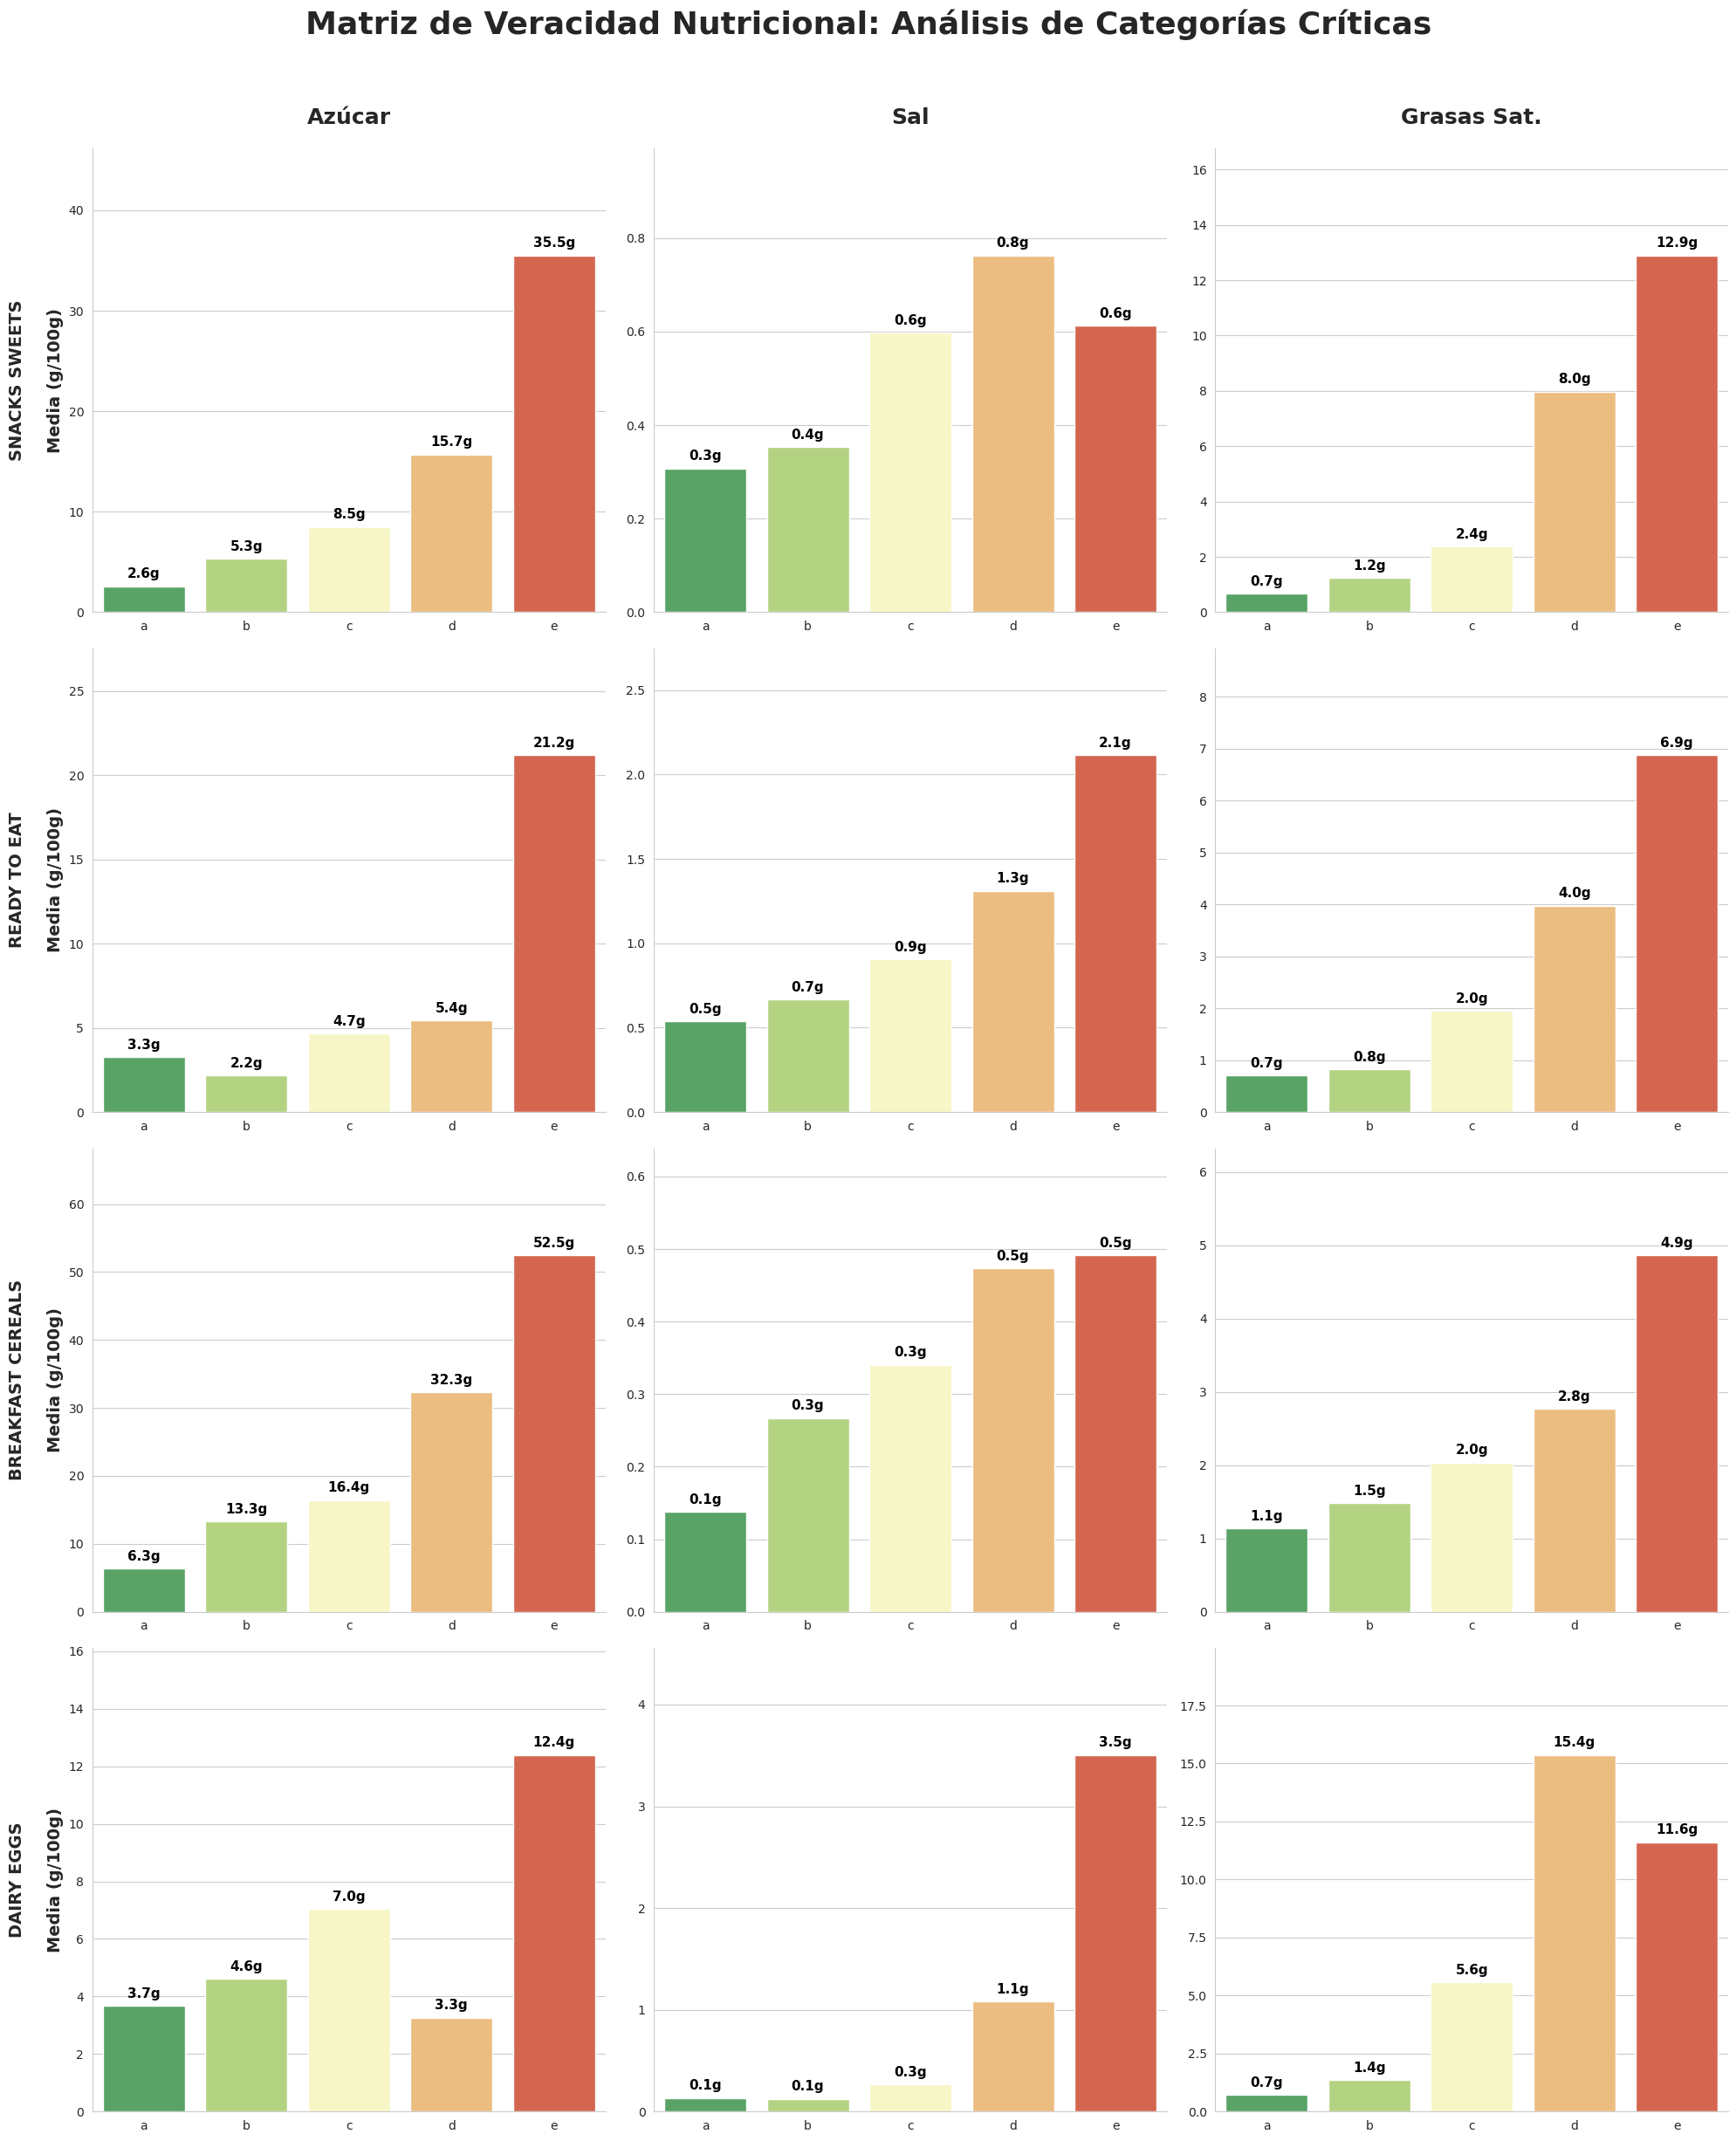

In [158]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparación: Incluimos 'breakfast_cereals' en el Top 4
top_categories = ['snacks_sweets', 'ready_to_eat', 'breakfast_cereals', 'dairy_eggs']
nutrientes = ['sugars_100g', 'salt_100g', 'saturated-fat_100g']
unidades = ['g', 'g', 'g']
titulos_nutri = ['Azúcar', 'Sal', 'Grasas Sat.']

# 2. Filtramos el dataset 'foods'
df_plot = foods[
    (foods['category_unified'].isin(top_categories)) & 
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e']))
].copy()

# 3. Configuración de la matriz 4x3
sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 3, figsize=(20, 24))
palette = "RdYlGn_r"
order = ['a', 'b', 'c', 'd', 'e']

# 4. Bucle para generar la matriz
for row, cat in enumerate(top_categories):
    for col, nutri in enumerate(nutrientes):
        ax = axes[row, col]
        
        # Filtramos datos para esta celda específica
        data_subset = df_plot[df_plot['category_unified'] == cat]
        
        # Calculamos la media para las barras
        medias_subset = data_subset.groupby('nutriscore_grade')[nutri].mean().reindex(order).reset_index()
        
        # Dibujamos el barplot
        sns.barplot(
            ax=ax, x='nutriscore_grade', y=nutri, data=medias_subset,
            order=order, palette=palette, hue='nutriscore_grade', legend=False
        )
        
        # Añadimos etiquetas de valor sobre las barras
        for p in ax.patches:
            val = p.get_height()
            if not pd.isna(val) and val > 0:
                ax.annotate(f'{val:.1f}{unidades[col]}', 
                            (p.get_x() + p.get_width() / 2., val), 
                            ha='center', va='center', 
                            xytext=(0, 10), textcoords='offset points', 
                            fontsize=11, fontweight='bold', color='black')

        # Títulos de columna (solo primera fila)
        if row == 0:
            ax.set_title(f"{titulos_nutri[col]}", fontsize=18, fontweight='bold', pad=20)
            
        # Etiquetas de fila (Categoría a la izquierda)
        if col == 0:
            nombre_label = cat.replace('_', ' ').upper()
            ax.set_ylabel(f"{nombre_label}\n\nMedia (g/100g)", fontsize=14, fontweight='bold')
        else:
            ax.set_ylabel("")
            
        ax.set_xlabel("")
        
        # Ajuste dinámico del límite Y para evitar cortes de etiquetas
        max_val = medias_subset[nutri].max()
        if max_val > 0:
            ax.set_ylim(0, max_val * 1.3)
        else:
            ax.set_ylim(0, 1)
            
        sns.despine(ax=ax)

plt.suptitle("Matriz de Veracidad Nutricional: Análisis de Categorías Críticas", 
             fontsize=26, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

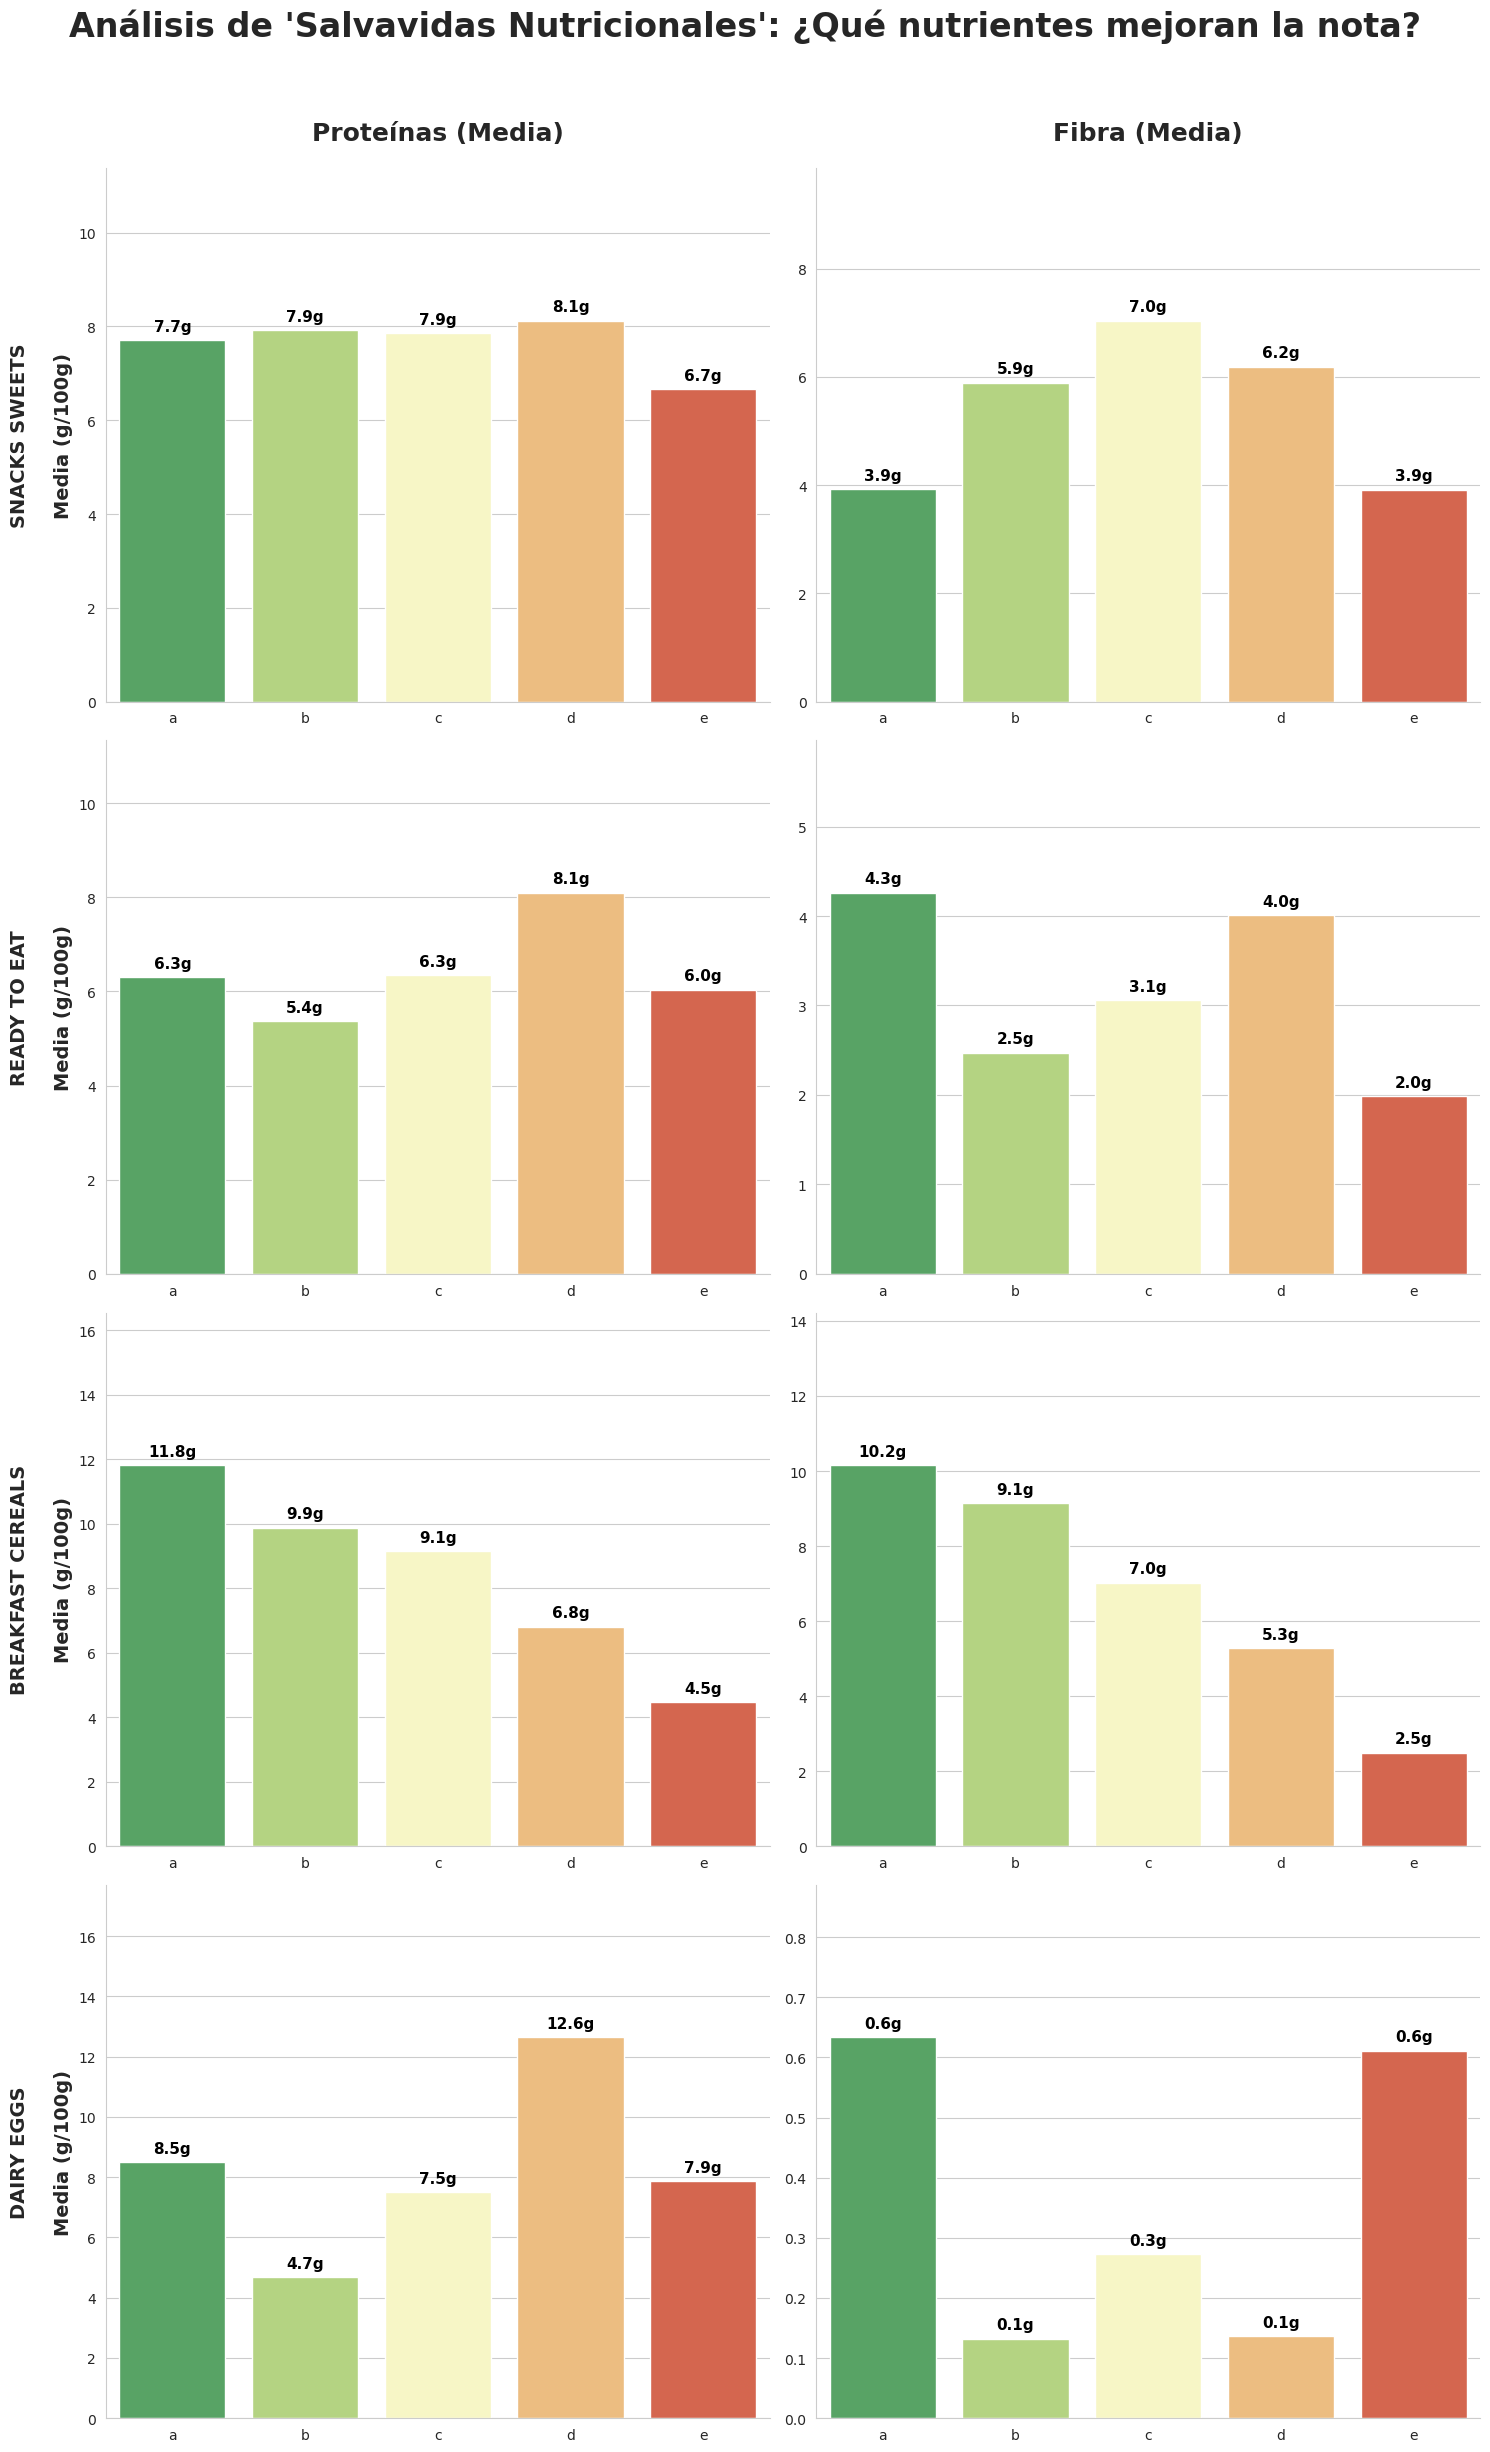

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparación: Añadimos 'breakfast_cereals' al Top 4 y nutrientes "positivos"
top_categories = ['snacks_sweets', 'ready_to_eat', 'breakfast_cereals', 'dairy_eggs']
nutrientes_pos = ['proteins_100g', 'fiber_100g']
titulos_pos = ['Proteínas (Media)', 'Fibra (Media)']

# Filtramos el dataset 'foods'
df_pos = foods[
    (foods['category_unified'].isin(top_categories)) & 
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e']))
].copy()

# 2. Configuración de la matriz 4x2
sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 2, figsize=(15, 24))
palette = "RdYlGn" # Invertimos la paleta para que el verde (bueno) esté en la 'A'
order = ['a', 'b', 'c', 'd', 'e']

# 3. Bucle para generar la matriz
for row, cat in enumerate(top_categories):
    for col, nutri in enumerate(nutrientes_pos):
        ax = axes[row, col]
        
        # Filtramos datos para esta celda específica
        data_subset = df_pos[df_pos['category_unified'] == cat]
        
        # Calculamos la media para las barras
        medias_subset = data_subset.groupby('nutriscore_grade')[nutri].mean().reindex(order).reset_index()
        
        # Dibujamos el barplot (usamos paleta 'RdYlGn' invertida para nutrientes positivos)
        sns.barplot(
            ax=ax, x='nutriscore_grade', y=nutri, data=medias_subset,
            order=order, palette="RdYlGn_r", hue='nutriscore_grade', legend=False
        )
        
        # Añadimos etiquetas de valor sobre las barras
        for p in ax.patches:
            val = p.get_height()
            if not pd.isna(val) and val > 0:
                ax.annotate(f'{val:.1f}g', 
                            (p.get_x() + p.get_width() / 2., val), 
                            ha='center', va='center', 
                            xytext=(0, 10), textcoords='offset points', 
                            fontsize=11, fontweight='bold', color='black')

        # Títulos de columna (solo primera fila)
        if row == 0:
            ax.set_title(f"{titulos_pos[col]}", fontsize=18, fontweight='bold', pad=20)
            
        # Etiquetas de fila (Categoría a la izquierda)
        if col == 0:
            nombre_label = cat.replace('_', ' ').upper()
            ax.set_ylabel(f"{nombre_label}\n\nMedia (g/100g)", fontsize=14, fontweight='bold')
        else:
            ax.set_ylabel("")
            
        ax.set_xlabel("")
        
        # Ajuste dinámico del límite Y
        max_val = medias_subset[nutri].max()
        if max_val > 0:
            ax.set_ylim(0, max_val * 1.4)
        else:
            ax.set_ylim(0, 1)
            
        sns.despine(ax=ax)

plt.suptitle("Análisis de 'Salvavidas Nutricionales': ¿Qué nutrientes mejoran la nota?", 
             fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

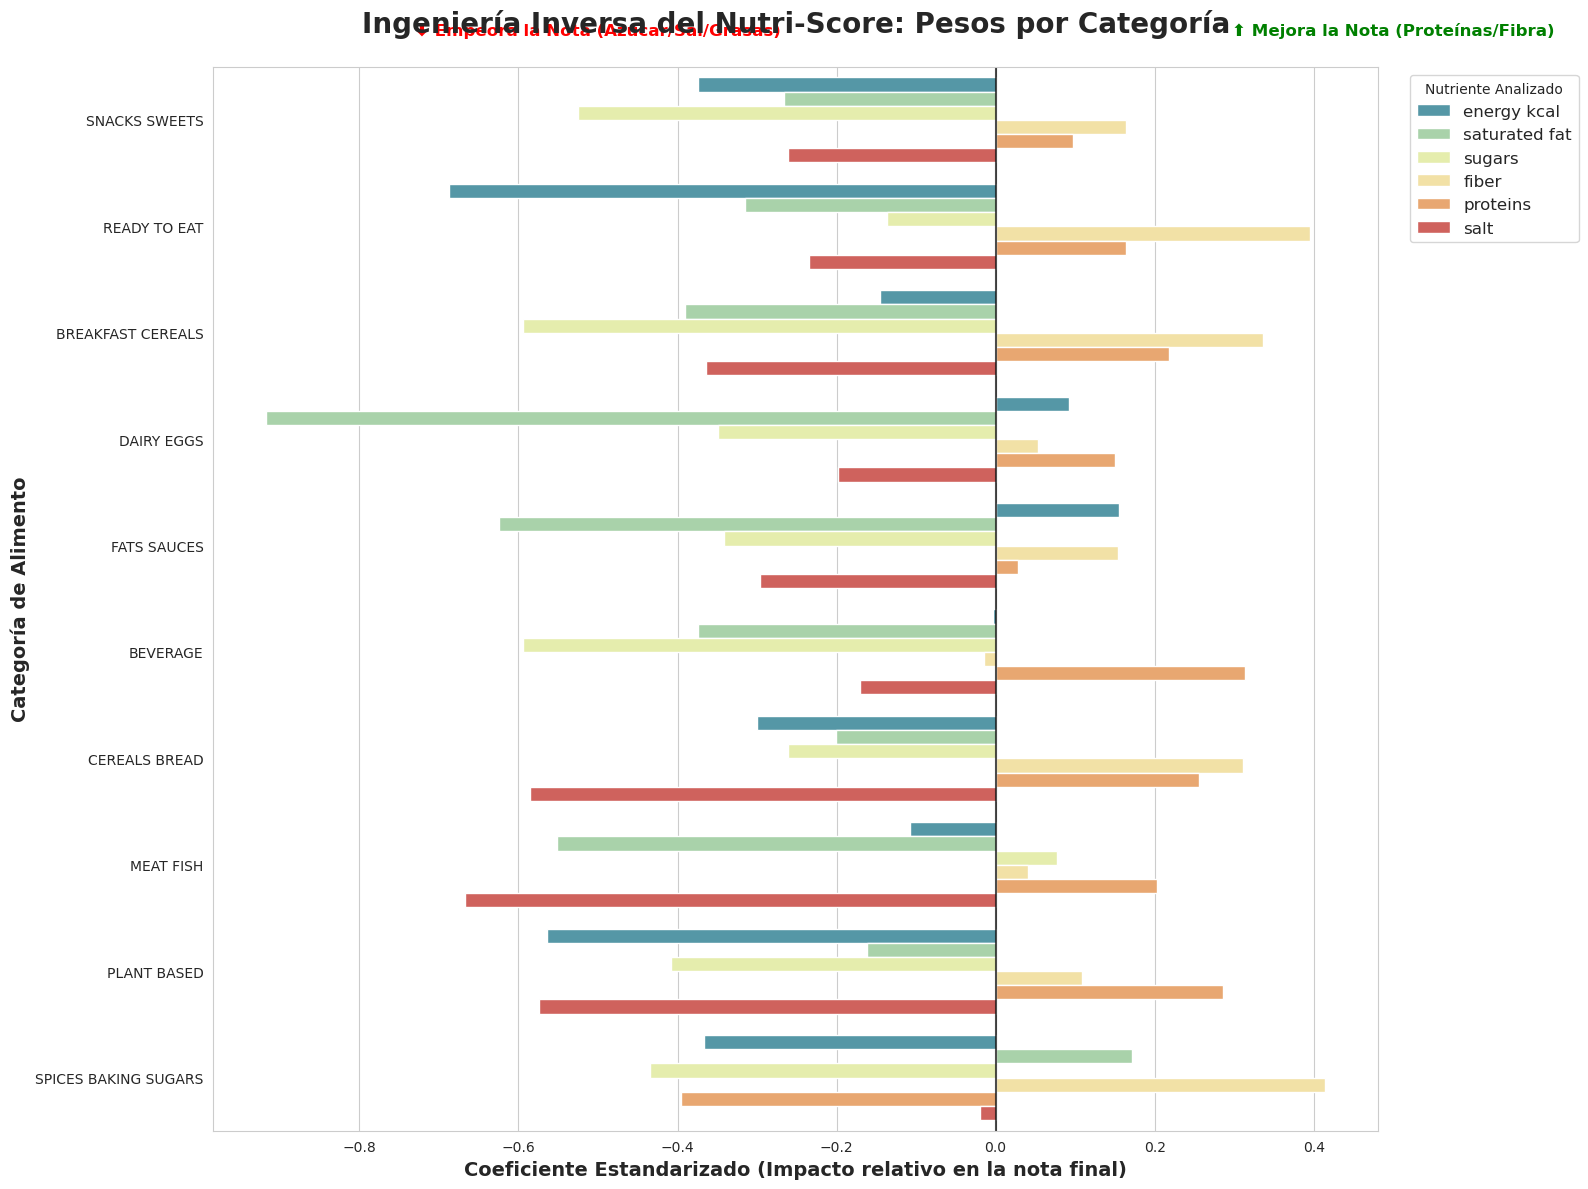

In [160]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# 1. Preparación del Dataset (A=5, E=1 para que los signos tengan sentido)
# Nota: Un coeficiente negativo significará que ese nutriente "baja" la nota (penalizador)
# Un coeficiente positivo significará que "sube" la nota (beneficioso)
df_reg = foods[foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])].copy()
df_reg['nutri_numeric'] = df_reg['nutriscore_grade'].map({'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1})

# Nutrientes del algoritmo oficial
nutrientes = ['energy-kcal_100g', 'saturated-fat_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g']

# Lista de categorías actualizada tras nuestro refinamiento
categories = [
    'snacks_sweets', 'ready_to_eat', 'breakfast_cereals', 'dairy_eggs', 
    'fats_sauces', 'beverage', 'cereals_bread', 'plant_based_alternatives', 
    'meat_fish', 'plant_based', 'spices_baking_sugars'
]

results = []

# 2. Motor de Regresión por Categoría
for cat in categories:
    # Filtramos por categoría y quitamos nulos
    cat_data = df_reg[df_reg['category_unified'] == cat].dropna(subset=nutrientes + ['nutri_numeric'])
    
    if len(cat_data) > 20: # Bajamos un poco el umbral para incluir categorías más pequeñas pero limpias
        X = cat_data[nutrientes]
        y = cat_data['nutri_numeric']
        
        # Estandarizamos para que el peso de la Sal (valores pequeños) sea comparable con Kcal (valores grandes)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Entrenamos el modelo
        model = LinearRegression()
        model.fit(X_scaled, y)
        
        # Guardamos los coeficientes
        for i, nutri in enumerate(nutrientes):
            results.append({
                'category': cat.replace('_', ' ').upper(),
                'nutrient': nutri.replace('_100g', '').replace('-', ' '),
                'coefficient': model.coef_[i]
            })

df_results = pd.DataFrame(results)

# 3. Visualización de "Pesos de Importancia"
plt.figure(figsize=(16, 12))
sns.set_style("whitegrid")

# Dibujamos el gráfico de barras horizontales
ax = sns.barplot(
    data=df_results, 
    x='coefficient', 
    y='category', 
    hue='nutrient', 
    palette="Spectral_r"
)

# Línea vertical en cero para distinguir beneficios de penalizaciones
plt.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)

# Títulos y formato
plt.title("Ingeniería Inversa del Nutri-Score: Pesos por Categoría", fontsize=20, pad=25, fontweight='bold')
plt.xlabel("Coeficiente Estandarizado (Impacto relativo en la nota final)", fontsize=14, fontweight='bold')
plt.ylabel("Categoría de Alimento", fontsize=14, fontweight='bold')
plt.legend(title="Nutriente Analizado", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)

# Añadimos flechas explicativas en el eje X para el usuario
plt.text(0.5, -0.8, "⬆️ Mejora la Nota (Proteínas/Fibra)", color='green', fontweight='bold', ha='center', fontsize=12)
plt.text(-0.5, -0.8, "⬇️ Empeora la Nota (Azúcar/Sal/Grasas)", color='red', fontweight='bold', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [161]:
import pandas as pd

# 1. Definimos los nutrientes a evaluar
nutrientes_criticos = ['sugars_100g', 'salt_100g', 'saturated-fat_100g']

impostores_list = []

# 2. Análisis por categoría para ser justos (no es lo mismo azúcar en un yogur que en un snack)
for cat in foods['category_unified'].unique():
    df_cat = foods[foods['category_unified'] == cat].copy()
    
    if len(df_cat) < 10: continue
    
    for nutri in nutrientes_criticos:
        # Calculamos el umbral del 25% superior en esa categoría
        umbral_alto = df_cat[nutri].quantile(0.75)
        
        # Buscamos los productos con nota A/B que superan ese umbral
        impostores = df_cat[
            (df_cat['nutriscore_grade'].isin(['a', 'b'])) & 
            (df_cat[nutri] > umbral_alto) &
            (df_cat[nutri] > 0) # Evitamos ceros
        ].copy()
        
        if not impostores.empty:
            impostores['nutriente_exceso'] = nutri
            impostores['valor_nutriente'] = impostores[nutri]
            impostores['umbral_cat'] = umbral_alto
            impostores_list.append(impostores)

# Unimos todos los hallazgos
df_impostores = pd.concat(impostores_list).drop_duplicates(subset=['product_name', 'nutriente_exceso'])

# 3. Ranking de los 10 casos más flagrantes (mayor diferencia respecto al umbral)
df_impostores['desviacion'] = df_impostores['valor_nutriente'] / df_impostores['umbral_cat']
top_mentiras = df_impostores.sort_values(by='desviacion', ascending=False).head(50)

print("TOP 10 PRODUCTOS CON NOTA A/B PERO EXCESO DE NUTRIENTES CRÍTICOS:")
top_mentiras[['product_name', 'category_unified', 'nutriscore_grade', 'nutriente_exceso', 'valor_nutriente']]

TOP 10 PRODUCTOS CON NOTA A/B PERO EXCESO DE NUTRIENTES CRÍTICOS:


,product_name,category_unified,nutriscore_grade,nutriente_exceso,valor_nutriente
3518,Bouillon Légumes,spices_baking_sugars,a,saturated-fat_100g,12.000000
3222,Eau de source de montagne,beverage,a,salt_100g,1.100000
2341,Fond de Veau,fats_sauces,b,salt_100g,16.800000
2182,Coco sans sucres,beverage,b,saturated-fat_100g,1.300000
5195,Haltbare Fettarme Milch,beverage,b,saturated-fat_100g,1.100000
1166,Coco Sans Sucres,beverage,b,saturated-fat_100g,1.100000
2388,gravy granules,fats_sauces,b,salt_100g,8.310000
6723,Nutty Granola,cereals_bread,a,saturated-fat_100g,4.700000
3518,Bouillon Légumes,spices_baking_sugars,a,salt_100g,31.000000
2069,Fruit Crunch Crisp,cereals_bread,a,sugars_100g,19.400000
